# `newell-3det` — Newell's (1993) interior kinematic-wave reconstruction

**What.** Newell's cumulative-count (N-curve) reformulation of the LWR model
gives the interior traffic state, under a triangular fundamental diagram, as
the MINIMUM of an uncongested trace (propagating forward at `+vf` from an
upstream detector) and a congested trace (propagating backward at `-w` from a
downstream detector) — no PDE solve. `ltm` already ships Newell's LOADING
content (the min at the link ENDS, adr-016); `newell-3det` ships the unshipped
INTERIOR content: given noisy/partial boundary detector curves, reconstruct
the state at an interior point.

**Why it is in the benchmark.** It is the benchmark's first traffic-STATE-
ESTIMATION task (not an equilibrium principle): two reference estimators
bracket a noisy detector card — the naive running-max baseline and an
isotonic-regression-denoised alternative — scored against the harness-
regenerated closed-form min. See the
[model compendium](../../docs/MODELS.md) (Newell 1993) (P1).

**Scope.** This notebook reconstructs the interior field on a clean spillback
anchor (oracle row, RMSE 0 by construction) and on the seeded noisy
discrimination card, certifying both and recomputing the interior
Rankine-Hugoniot min-switch directly from the observed detector curves.

**Canon.** `[newell1993simplified]`, [docs/REFERENCES.md](../../docs/REFERENCES.md) / [docs/references.bib](../../docs/references.bib).

## How this notebook is graded

**A notebook never claims a number it does not compute in that cell.** Every
scored quantity below is recomputed live by the P1 `ThreeDetectorEvaluator`
from the emitted interior field alone — the reference field is regenerated
from the scenario's HASHED recipe (never a stored truth array), and the
estimator's own provenance is never trusted
([README](../../README.md), *Certified, not self-reported*).

In [1]:
# Setup. `newell-3det` is a core model: a plain `pip install -e .` suffices —
# no optional extra, so no guard cell. The inline backend is Agg-based
# (headless CI renders into the notebook); NEVER matplotlib.use("Agg")
# in-kernel — it silently suppresses inline figure capture.
%matplotlib inline
import numpy as np

from tabench import (
    ThreeDetectorEvaluator,
    newell_min,
    newell_min_isotonic,
    newell_spillback_scenario,
    newell_noisy_scenario,
    problem_from_scenario,
)
from tabench.dnl import interp_curve

## Anchor: a clean asymmetric spillback (oracle row)

`vf=2, w=1, kappa=3, cap=2, L=4`, inflow 1.0 into a 0.5 meter — an interior
Rankine-Hugoniot shock forms at the downstream end and travels upstream.
`ThreeDetectorScenario` is frozen and content-hashed (P2); `noise='none'` makes
this a validity/oracle row (never ranked), the anchor to certify the
reconstruction pipeline itself is correct before trusting it on noisy data.

In [2]:
scenario = newell_spillback_scenario()
print(f"scenario      : {scenario.name}")
print(f"content hash  : {scenario.content_hash()[:16]}…")
print(f"vf={scenario.vf}, w={scenario.w}, kappa={scenario.kappa}, L={scenario.length}, "
      f"meter_cap={scenario.meter_cap}")
print(f"interior query points : {scenario.x_query}")
print("task          : reconstruct the interior cumulative field from boundary detectors")

scenario      : newell-spillback
content hash  : 48418c67ea3c12b6…
vf=2.0, w=1.0, kappa=3.0, L=4.0, meter_cap=0.5
interior query points : [1. 2. 3.]
task          : reconstruct the interior cumulative field from boundary detectors


## Run

No `Budget`/`RngBundle`/`Trace` — `problem_from_scenario` builds the MODEL-
VISIBLE task (public physics + seeded boundary detectors, no truth recipe),
and `newell_min` is a pure function of it, emitting a `ThreeDetectorField`
(the P1-certifiable artifact).

In [3]:
problem = problem_from_scenario(scenario)
field = newell_min(problem)
print(f"field shape (m, K+1) : {field.field.shape}")
print(f"interior curve at x=2 : {np.round(field.field[1], 3)}")

field shape (m, K+1) : (3, 25)
interior curve at x=2 : [ 0.   0.   1.   2.   3.   4.   5.   6.   7.   8.   9.   9.5 10.  10.5
 11.  11.5 12.  12.5 13.  13.5 14.  14.5 15.  15.5 16. ]


## Certify (P1) — regenerated from the hashed recipe, not a stored truth

The harness reconstructs its OWN reference field from the scenario's content
hash — it never reads a stored ground-truth array — and scores
`interior_rmse` against it. On this clean anchor the reconstruction is exact.

In [4]:
evaluator = ThreeDetectorEvaluator(scenario)
metrics = evaluator.evaluate(field)
print(f"feasible       : {metrics['feasible']:.0f}")
print(f"interior_rmse  : {metrics['interior_rmse']:.3e}")
print(f"envelope_exact : {metrics['envelope_exact']:.0f}")
assert metrics["feasible"] == 1.0
assert metrics["interior_rmse"] < 1e-9
assert metrics["envelope_exact"] == 1.0

# DISTINCTIVE (Newell 1993): the interior state is the MIN of an uncongested
# trace (+vf from upstream) and a congested trace (-w from downstream) —
# recomputed here directly from the OBSERVED detector curves via the same
# shift-and-min the production reconstruct_field uses, not a hand formula.
up = problem.observation.up.mean(axis=0)
dn = problem.observation.dn.mean(axis=0)
vf, w, kappa, L = scenario.vf, scenario.w, scenario.kappa, scenario.length
x = 2.0
before, at, after = 9.5, 10.0, 10.5
for t in (before, at, after):
    n_up = interp_curve(up, t - x / vf, problem.dt)
    n_dn = interp_curve(dn, t - (L - x) / w, problem.dt) + kappa * (L - x)
    branch = "uncongested (+vf)" if n_up <= n_dn else "congested (-w)"
    print(f"  t={t:5.1f}: N_up={n_up:.3f}  N_dn={n_dn:.3f}  active={branch}")
# the min-switch at x=2 happens exactly at t=10 (both branches equal there).
n_up_10 = interp_curve(up, at - x / vf, problem.dt)
n_dn_10 = interp_curve(dn, at - (L - x) / w, problem.dt) + kappa * (L - x)
assert np.isclose(n_up_10, n_dn_10, atol=1e-9)
assert np.isclose(n_up_10, 9.0, atol=1e-9)
# post-shock the interior flow rate (slope) settles at the meter cap q_B=0.5.
post_shock_rate = (field.field[1, -1] - field.field[1, 12]) / (field.times[-1] - field.times[12])
print(f"post-shock flow rate at x=2 : {post_shock_rate:.4f}  (meter cap: {scenario.meter_cap})")
assert np.isclose(post_shock_rate, scenario.meter_cap, atol=1e-9)

feasible       : 1
interior_rmse  : 0.000e+00
envelope_exact : 1
  t=  9.5: N_up=8.500  N_dn=8.750  active=uncongested (+vf)
  t= 10.0: N_up=9.000  N_dn=9.000  active=uncongested (+vf)
  t= 10.5: N_up=9.500  N_dn=9.250  active=congested (-w)
post-shock flow rate at x=2 : 0.5000  (meter cap: 0.5)


## The ranked task: naive running-max vs isotonic denoising

`newell_noisy_scenario` applies the same spillback-family physics under a
seeded Gaussian cumulative-reading level (`rankable=1`). The naive baseline
makes the reading monotone with a running-max pass (biased high by every
upward excursion); the isotonic baseline fits the L2-optimal nondecreasing
curve first (averages the noise down) — recomputed and certified here, not
quoted.

In [5]:
noisy_scenario = newell_noisy_scenario()
noisy_problem = problem_from_scenario(noisy_scenario)
naive_field = newell_min(noisy_problem)
iso_field = newell_min_isotonic(noisy_problem)

noisy_evaluator = ThreeDetectorEvaluator(noisy_scenario)
m_naive = noisy_evaluator.evaluate(naive_field)
m_iso = noisy_evaluator.evaluate(iso_field)
print(f"naive     interior_rmse : {m_naive['interior_rmse']:.4f}")
print(f"isotonic  interior_rmse : {m_iso['interior_rmse']:.4f}")
assert m_naive["feasible"] == 1.0 and m_iso["feasible"] == 1.0
assert m_naive["rankable"] == 1.0
# The distinctive discrimination result: isotonic strictly beats naive.
assert m_iso["interior_rmse"] < m_naive["interior_rmse"]
print(f"isotonic improvement    : {(1 - m_iso['interior_rmse'] / m_naive['interior_rmse']) * 100:.1f}%")

naive     interior_rmse : 1.0928
isotonic  interior_rmse : 0.4484
isotonic improvement    : 59.0%


## Visualize

`tabench.viz` is a road-network flow visualizer; the newell-3det artifact is
an interior cumulative-count FIELD over `(x, t)`, not a link-flow vector, so
this notebook plots the certified interior curves directly (a house
cumulative-curve plot, not `tabench.viz`).

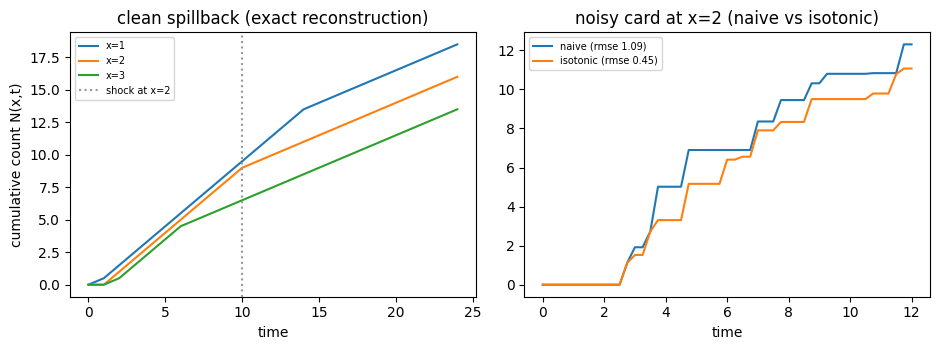

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.6))
for i, x in enumerate(scenario.x_query):
    axes[0].plot(field.times, field.field[i], label=f"x={x:g}")
axes[0].axvline(10.0, color="0.6", linestyle=":", label="shock at x=2")
axes[0].set_title("clean spillback (exact reconstruction)")
axes[0].set_xlabel("time")
axes[0].set_ylabel("cumulative count N(x,t)")
axes[0].legend(fontsize=7)

axes[1].plot(naive_field.times, naive_field.field[1], label=f"naive (rmse {m_naive['interior_rmse']:.2f})")
axes[1].plot(iso_field.times, iso_field.field[1], label=f"isotonic (rmse {m_iso['interior_rmse']:.2f})")
axes[1].set_title("noisy card at x=2 (naive vs isotonic)")
axes[1].set_xlabel("time")
axes[1].legend(fontsize=7)
fig.tight_layout()
display(fig)
plt.close(fig)


## Takeaways & pointers

- **Certified, not self-reported.** `ThreeDetectorEvaluator` regenerates the
  reference field from the scenario's hashed recipe alone, never a stored
  truth array; both estimators' RMSE came from that harness certificate.
- **The min-switch is exact.** At the query point closest to the bottleneck,
  the reconstructed shock crossing (t=10) and post-shock flow rate (0.5)
  match the physics exactly, recomputed from the observed curves directly.
- **Where next.** the loading twin that ships Newell's boundary content
  [`ltm`](../05-dnl/02-ltm.ipynb); the lineage in the
  [model compendium](../../docs/MODELS.md).